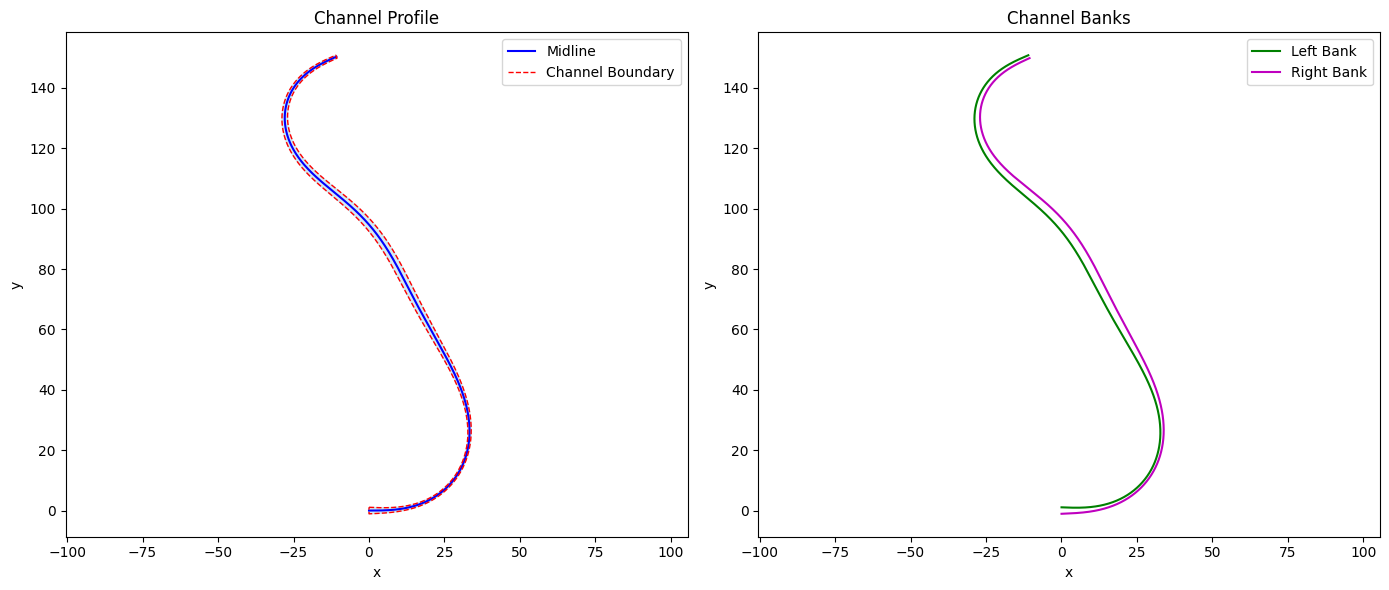

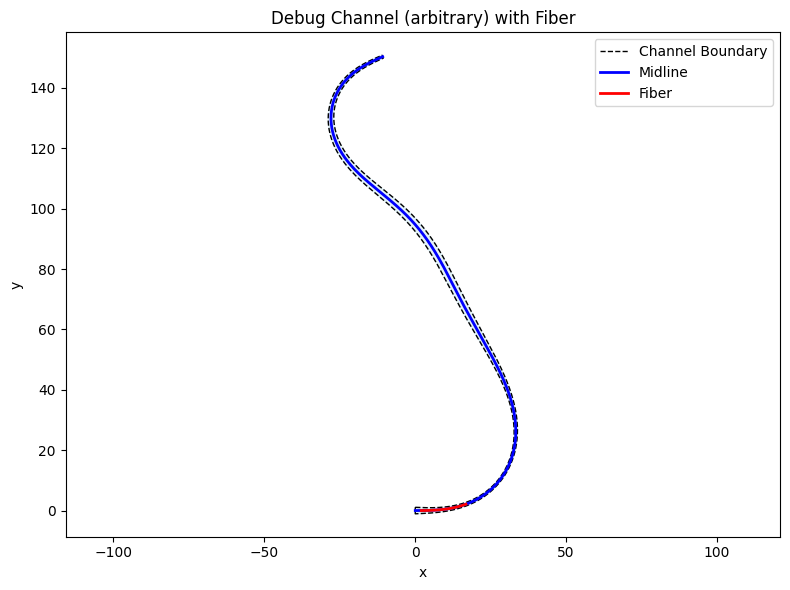

In [ ]:
import os
import bo_sheet.channel_preprocess_utility as cu
import numpy as np
from colorama import init
init()

'simple_straight'
'arc'
'straight'
's_shaped'
'sinusoidal'
'arbitrary'

channel_type = cu.ChannelType.arbitrary.value
L_total = 200.0 # For arbitrary, recommend 200 or larger

# Arbitrary is always non-constant width
constant_width = True

# If constant_width is True
width = 2.0

# If constant_width is False
num_width_ctrl = 5 # Must be >= 2
min_width = 1.0
max_width = 2.8
max_rate_width = 1.0

origin_offset = 0.0
N_points = 1000

# Applicable to arc, s_shaped, sinusoidal, arbitrary settings ================================================

min_curvature = 0.002
max_curvature = 0.02
max_rate_curvature = 0.001

# For s_shaped and sinusoidal
amplitude = 2.0

# For sinusoidal
frequency = 1.5

# For arc
radius = 10.0

# For arbitrary
n_bending = 4

channel_directory = os.path.join(os.path.expanduser('~'),
                                      'Documents', 'GitHub', 'Bayesian_Optimization_for_Sheet_Robots',
                                      'tasks', '1_run_sim_trials')

# End of channel settings ====================================================================================

x_midline, y_midline, channel_polygon, left_bank, right_bank = cu.generate_closed_channel(
    L_total, n_bending, num_width_ctrl, max_curvature, min_curvature, max_width,
    min_width, max_rate_curvature, max_rate_width, channel_type, width,
    amplitude, frequency, radius, constant_width, origin_offset, N_points
)

cu.plot_channel_all_info(x_midline, y_midline, channel_polygon, left_bank, right_bank)

with open(os.path.join(channel_directory, channel_type, "polygon.wkt"), "w") as file:
    file.write(channel_polygon.wkt)
file.close()

channel_info = {
    "x_midline": x_midline,
    "y_midline": y_midline,
    "left_bank": left_bank,
    "right_bank": right_bank
}

np.savez(os.path.join(channel_directory, channel_type, 'channel_info'), **channel_info)

seg_midline = np.column_stack((x_midline, y_midline))  # Shape: (M, 2)

L_fiber = 15.0
offset_factor = 0.01  # Start fiber at 1% along midline
N_fiber = 50

fiber = cu.generate_fiber_in_segment(seg_midline, L_fiber=L_fiber, offset_factor=offset_factor, N_fiber=N_fiber)
cu.plot_channel_and_fiber(channel_polygon, seg_midline, fiber, title=f"Debug Channel ({channel_type}) with Fiber")